# **Perbandingan Tokenizer**
Pada bagian ini akan dilakukan perbandingan dari tokenizer dari berbagai **vocabulay size** pada **indmixedtufs4**. Tujuan dari percobaan ini adalah untuk menilai seberapa baik tokenizer dapat melakukan tokenisasi dengan baik (memecah token secara utuh)

# Import Library

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns  

from transformers import BartTokenizer

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Load Dataset

In [2]:
# mix_datasets_8k_path = kagglehub.dataset_download('jawahirul/mix-datasets-8k')

df = pd.read_csv('/kaggle/input/fine-tuning/fine-tuning.csv')

documents = df['text'].tolist()

## Coba Tokenisasi

In [3]:
# index = documents[5]
# print(index)

In [4]:
# Load Custom tokenizer
indmixtufs4_50k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-indomixedtufs4/transformers/tokenizer-indomixedtufs4-50265/1')

# Pilih pilih index dokumen
document_index = 5
selected_doc = documents[document_index]

# Tokenisasi menggunakan tokenizer custom
tokens = indmixtufs4_50k.encode(selected_doc, add_special_tokens=False)
decoded_tokens = indmixtufs4_50k.convert_ids_to_tokens(tokens)  # Token hasil tokenisasi

# Tokenisasi menggunakan word tokenization dari NLTK
nltk_tokens = word_tokenize(selected_doc)

# Tampilkan hasil
# print(f"Dokumen asli:\n{selected_doc}\n")

print(f"Jumlah token (word tokenization NLTK): {len(nltk_tokens)}")
# print(f"Token hasil tokenisasi (word tokenization NLTK):\n{nltk_tokens}\n")

print(f"Jumlah token (custom tokenizer): {len(tokens)}")
# print(f"Token hasil tokenisasi (custom tokenizer):\n{decoded_tokens}\n")

Jumlah token (word tokenization NLTK): 1745
Jumlah token (custom tokenizer): 2009


# Evaluasi Tokenizer

## Check Total Token

In [5]:
# LOAD TOKENIZER
# Load indo-mixtuf4 tokenizer
indmixedtufs4_10k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-indomixedtufs4/transformers/tokenizer-indomixedtufs4-10000/1')
indmixedtufs4_30k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-indomixedtufs4/transformers/tokenizer-indomixedtufs4-30000/1')
indmixedtufs4_50k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-indomixedtufs4/transformers/tokenizer-indomixedtufs4-50265/1')

# Fungsi untuk menghitung total kata dan token
def total_token(documents):
    word_counts = []
    indmixedtufs4_10k_counts = []
    indmixedtufs4_30k_counts = []
    indmixedtufs4_50k_counts = []

    for doc in documents:
            
        # Hitung jumlah kata dengan NLTK
        words = word_tokenize(doc)
        word_counts.append(len(words))

        # Hitung jumlah token dengan custom tokenizer
        indmixedtufs4_token_10k = indmixedtufs4_10k.encode(doc, add_special_tokens=False)
        indmixedtufs4_10k_counts.append(len(indmixedtufs4_token_10k))

        indmixedtufs4_token_30k = indmixedtufs4_30k.encode(doc, add_special_tokens=False)
        indmixedtufs4_30k_counts.append(len(indmixedtufs4_token_30k))

        indmixedtufs4_token_50k = indmixedtufs4_50k.encode(doc, add_special_tokens=False)
        indmixedtufs4_50k_counts.append(len(indmixedtufs4_token_50k))

    # Hitung total kata
    total_word_count = sum(word_counts)
    total_indmixedtufs4_10k = sum(indmixedtufs4_10k_counts)
    total_indmixedtufs4_30k = sum(indmixedtufs4_30k_counts)
    total_indmixedtufs4_50k = sum(indmixedtufs4_50k_counts)

    return total_word_count, total_indmixedtufs4_10k, total_indmixedtufs4_30k, total_indmixedtufs4_50k


In [6]:
# Format output ke ribuan
def format_thousands(number):
    return "{:,}".format(int(number)).replace(",", ".")
    
# Hitung total kata dan token
total_word_count, total_indmixedtufs4_10k, total_indmixedtufs4_30k, total_indmixedtufs4_50k = total_token(documents)

# Print hasil
print(f"Total kata (NLTK): {format_thousands(total_word_count)}")
print(f"Total token (Indomixedtufs4-10k): {format_thousands(total_indmixedtufs4_10k)}")
print(f"Total token (Indomixedtufs4-30k): {format_thousands(total_indmixedtufs4_30k)}")
print(f"Total token (Indomixedtufs4-50k): {format_thousands(total_indmixedtufs4_50k)}")

Total kata (NLTK): 3.798.826
Total token (Indomixedtufs4-10k): 5.432.148
Total token (Indomixedtufs4-30k): 4.619.804
Total token (Indomixedtufs4-50k): 4.418.597


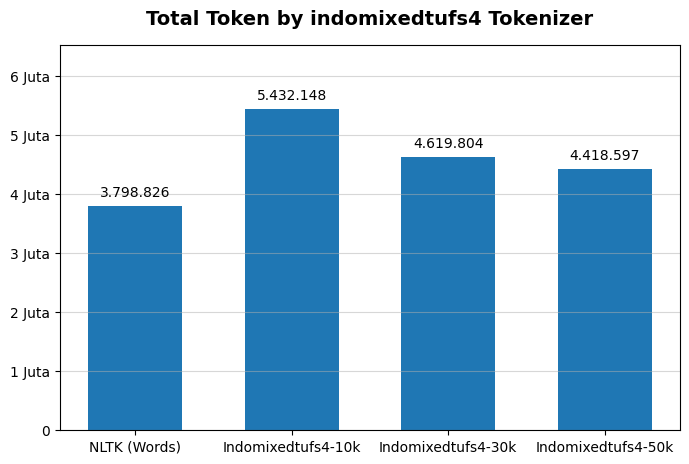

In [7]:
# Fungsi untuk visualisasi
def plot_total_token(total_word_count, total_indmixedtufs4_10k, total_indmixedtufs4_30k, total_indmixedtufs4_50k):
    labels = ['NLTK (Words)', 'Indomixedtufs4-10k', 'Indomixedtufs4-30k', 'Indomixedtufs4-50k']
    values = [total_word_count, total_indmixedtufs4_10k, total_indmixedtufs4_30k, total_indmixedtufs4_50k]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, width=0.6)
    
    # Set juda=ul dan label
    plt.title('Total Token by indomixedtufs4 Tokenizer', fontweight='semibold', fontsize=14, pad=15)    
    # plt.ylabel('Total Token', fontsize=13, labelpad=10)
    # plt.xlabel('Tokenization Method', fontsize=13, labelpad=20)

    # Set grid dan panjang bar
    plt.grid(True, axis='y', alpha=0.5)
    plt.ylim(0, max(values) * 1.2) # mengatur panjang bar

    # Tambahkan nilai di atas setiap bar
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.03, format_thousands(v), ha='center', fontsize=10)

    def juta_formatter(x, pos):
        """Mengubah angka tick menjadi format jutaan (misal: 2 Jt, 5.5 Jt)"""
        if x == 0:
            return '0'
        else:
            val_jt = x / 1e6
            # Jika nilainya adalah bilangan bulat setelah dibagi sejuta (misal 2.0, 3.0)
            # tampilkan tanpa desimal. Jika tidak (misal 2.5), tampilkan satu desimal.
            if val_jt == int(val_jt):
                return f'{val_jt:.0f} Juta'
            else:
                return f'{val_jt:.1f} Juta'

    # Dapatkan axes saat ini dan terapkan formatter ke sumbu Y
    ax = plt.gca()
    ax.yaxis.set_major_formatter(FuncFormatter(juta_formatter))

    # plt.tight_layout()
    plt.show()

#Visualisasi hasil
plot_total_token(total_word_count, total_indmixedtufs4_10k, total_indmixedtufs4_30k, total_indmixedtufs4_50k)


## Fertility Metric

In [8]:
# Fungsi   menghitung metrik fertility dari total token
def fertility_metric(total_word_count, total_tokens_10k, total_tokens_30k, total_tokens_50k):
    # Hitung fertility (total token / total kata asli)
    fertility_10k = total_tokens_10k / total_word_count
    fertility_30k = total_tokens_30k / total_word_count 
    fertility_50k = total_tokens_50k / total_word_count 

    return fertility_10k, fertility_30k, fertility_50k

In [9]:
# Hitung fertility dari total
fertility_10k, fertility_30k, fertility_50k = fertility_metric(
    total_word_count, total_indmixedtufs4_10k, total_indmixedtufs4_30k, total_indmixedtufs4_50k
)
    
# Print hasil fertility
print(f"Fertility (Indomixedtuf4-10k): {fertility_10k:.2f}")
print(f"Fertility (Indomixedtuf4-30k): {fertility_30k:.2f}")
print(f"Fertility (Indomixedtuf4-50k): {fertility_50k:.2f}")

Fertility (Indomixedtuf4-10k): 1.43
Fertility (Indomixedtuf4-30k): 1.22
Fertility (Indomixedtuf4-50k): 1.16


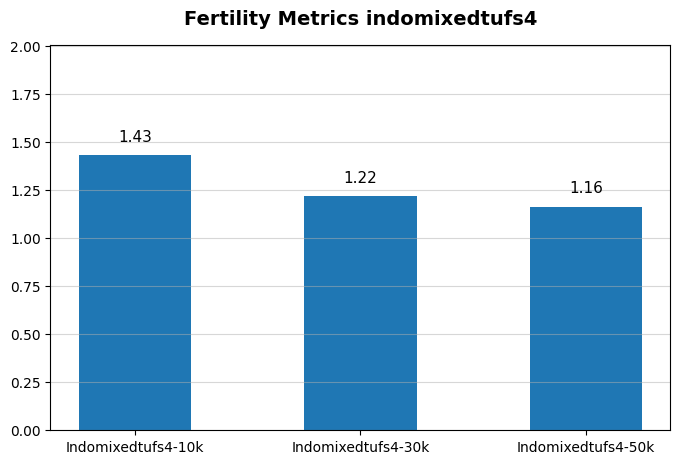

In [10]:
# Fungsi visualisasi fertility
def plot_fertility(fertility_10k, fertility_30k, fertility_50k):
    labels = ['Indomixedtufs4-10k', 'Indomixedtufs4-30k', 'Indomixedtufs4-50k']
    values = [fertility_10k, fertility_30k, fertility_50k]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, width=0.5)

    # Set judul dan label
    plt.title('Fertility Metrics indomixedtufs4', fontweight='semibold', fontsize=14, pad=15)
    # plt.ylabel('Tokens per Word', fontsize=13, labelpad=10)
    # plt.xlabel('Tokenizer', fontsize=13, labelpad=20)

    # Set grid dan panjang bar
    plt.grid(True, axis='y', alpha=0.5)
    plt.ylim(0, max(values) * 1.4) # Mengatur panjang bar

    # # Set ukuran font pada label
    # plt.xticks(fontsize=11)

    # Tambahkan nilai di atas setiap bar
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.05, f"{v:.2f}", ha='center', fontsize=11)

    # Tampilkan plot
    plt.show()

# Visualisasi fertility
plot_fertility(fertility_10k, fertility_30k, fertility_50k)

# Contoh hasil tokenisasi tokenizer indomixedtufs4

In [11]:
# Input teks
text = 'Hindari gratifikasi untuk pemilu bersih.'

# Buat dictionary untuk menyimpan tokenizer Anda agar mudah diakses
tokenizers = {
    "indmixedtufs4-10k": indmixedtufs4_10k,
    "indmixedtufs4-30k": indmixedtufs4_30k,
    "indmixedtufs4-50k": indmixedtufs4_50k
}

def proses_encode_decode(tokenizer_name, tokenizer, text_input):
    
    print(f"--- Proses untuk {tokenizer_name} ---")

    # 1. Encode string ke ID token
    encoded_output = tokenizer.encode(text_input, return_tensors="pt")
    print(f"Encode {tokenizer_name}:\n{encoded_output}\n")

    # 2. Decode ID token ke string (keseluruhan)
    decoded_full_text = tokenizer.decode(encoded_output[0], skip_special_tokens=False)
    print(f"Decode {tokenizer_name} (keseluruhan):\n{decoded_full_text}\n")

    # 3. Decode masing-masing ID token
    print(f"Decode {tokenizer_name} (per token):")
    token_ids = encoded_output[0]  # Mengambil ID token
    decoded_individual_tokens = []
    
    for token_id in token_ids:
        # Ubah token_id menjadi list agar bisa di-decode
        decoded_token = tokenizer.decode([token_id.item()], skip_special_tokens=False)
        decoded_individual_tokens.append(decoded_token)
        print(f"  ID: {token_id.item():<5} -> Token: '{decoded_token}'")
        
    print(f"\n Total token {tokenizer_name}: {len(decoded_individual_tokens)}")
    print(decoded_individual_tokens)
    print("-" * 40 + "\n") # Pemisah antar tokenizer

# Loop melalui setiap tokenizer dan proses teksnya
for name, tokenizer_object in tokenizers.items():
    proses_encode_decode(name, tokenizer_object, text)
    

--- Proses untuk indmixedtufs4-10k ---
Encode indmixedtufs4-10k:
tensor([[   0,   44, 2751, 4591, 1123,  838,  364, 7390, 3339,   18,    2]])

Decode indmixedtufs4-10k (keseluruhan):
<s>Hindari gratifikasi untuk pemilu bersih.</s>

Decode indmixedtufs4-10k (per token):
  ID: 0     -> Token: '<s>'
  ID: 44    -> Token: 'H'
  ID: 2751  -> Token: 'indari'
  ID: 4591  -> Token: ' gr'
  ID: 1123  -> Token: 'atif'
  ID: 838   -> Token: 'ikasi'
  ID: 364   -> Token: ' untuk'
  ID: 7390  -> Token: ' pemilu'
  ID: 3339  -> Token: ' bersih'
  ID: 18    -> Token: '.'
  ID: 2     -> Token: '</s>'

 Total token indmixedtufs4-10k: 11
['<s>', 'H', 'indari', ' gr', 'atif', 'ikasi', ' untuk', ' pemilu', ' bersih', '.', '</s>']
----------------------------------------

--- Proses untuk indmixedtufs4-30k ---
Encode indmixedtufs4-30k:
tensor([[    0, 20132,  4591, 12204,   364,  7390,  3339,    18,     2]])

Decode indmixedtufs4-30k (keseluruhan):
<s>Hindari gratifikasi untuk pemilu bersih.</s>

Decode in